# Clase 36 - Notebook 2 - algoritmo de optimización NSGA-II
En este Notebook abordamos la simulación y optimización de este proceso mediante un modelo dinámico que describe la evolución de las variables del secador. El problema de optimización multiobjetivo busca minimizar simultáneamente el **contenido energético, $E$** de la corriente de aire caliente y la **humedad residual, $X_0$** del polvo. Las variables de decisión son: flujo másico del **aire a la entrada del secador, $G$** y el **radio inicial de las gotas, $r_d$** que ingresan al secador.

$$
\begin{aligned}
& \text{Minimize} \quad ContenidoEnergetico,\ X_0 \\[4pt]
& \text{subject to} \\[2pt]
\end{aligned}
$$
$$
462 \le G \le 858, \\[2pt]
3.5 \cdot 10^{-5} \le r_d \le 6.5 \cdot 10^{-5}
$$

donde:
* $G$ es el caudal de aire seco (kg/s).
* $r_d$ es el radio incial de la gota (m).


# 02 — NSGA-II (pymoo)
Genera el frente y guarda CSV/figura en `./outputs`.

Tiempo aprox: 273.95 s
Guardado: ./outputs/front_nsga2_20250819-183417.csv | puntos: 100


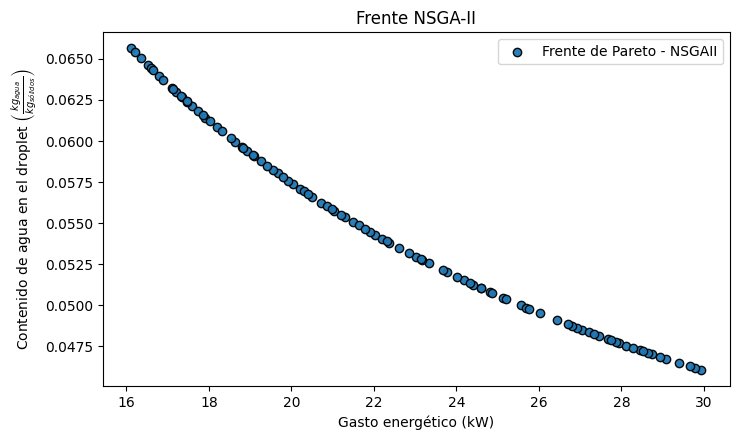

In [4]:
# --- Preámbulo Universal para Google Colab y Entornos Locales ---
import os, sys

if 'google.colab' in sys.modules:
    REPO_DIR = '/content/DAII-SprayDrying'
    if not os.path.exists(REPO_DIR):
        !git clone https://github.com/felipehuerta17/DAII-SprayDrying.git {REPO_DIR}
    os.chdir(REPO_DIR)
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)
    %pip install -q numpy scipy pandas matplotlib pymoo casadi


El frente de pareto utilizando el algoritmo NSGA-II muestra objetivos competitivos: disminuir el gasto energético requiere aumentar el contenido de agua en la gotita. El frente de pareto queda guardado en el archivo `./outputs/front_nsga2_{stamp}.csv`, donde stamp es la fecha de ejecución. El frente muestra puntos óptimos cerca unos de otros, lo que también se denomina un frente denso. Esto es una buena indicación de que se calculó un número suficiente de soluciones óptimas.

# Selección manual de soluciones óptimas
- En el Notebook 4 revisaremos algoritmos de toma de decisiones automáticos. No obstante, el frente presenta información invaluable para los profesionales que manejen el secador Spray y deban adaptar sus condiciones de operación a condiciones de regulación o mercado.
- A partir de todas estas soluciones óptimas, el ingeniero puede optar por aquella más útil para el contexto operativo o estratégico de la empresa.


In [5]:
df = pd.DataFrame(np.hstack([X,F]), columns=["G_kg_h","rd_m","Energia_kW","Xo_prom_ultimos"])
df.to_csv(csv, index=False)
print("Guardado:", csv, "| puntos:", len(X))

Guardado: ./outputs/front_nsga2_20250819-183417.csv | puntos: 100


En este punto podemos operar directamente con el archivo .csv generado, o utilizar las funciones de Pandas Dataframe para obtener conclusiones rápidas. Por ejemplo, si quisiéramos ver cuales son las variables de decisión que entregan los puntos óptimos para 5 diez simulaciones con menor costo de energía, podemos ejecutar el siguiente código:

In [6]:
df.sort_values(by="Energia_kW").head(5)

,G_kg_h,rd_m,Energia_kW,Xo_prom_ultimos
1,462.003241,0.000047,16.121988,0.065643
99,464.708155,0.000049,16.216378,0.065398
8,468.566376,0.000036,16.351014,0.065054
7,473.653004,0.000041,16.528516,0.064608
62,475.808260,0.000044,16.603726,0.064422


Es interesante notar que casi todos estos casos utilizan un radio de gotita relativamente alto, salvo el tercer caso.

Por otra parte, si deseáramos hacer lo mismo con el contenido de humedad, cambiamos el argumento de la función `sort_values` por `Xo_prom_ultimos`,

In [7]:
df.sort_values(by="Xo_prom_ultimos").head(5)

,G_kg_h,rd_m,Energia_kW,Xo_prom_ultimos
0,857.999982,0.000063,29.940624,0.046039
72,853.768479,0.000060,29.792963,0.046153
96,849.804344,0.000059,29.654631,0.046262
93,842.684475,0.000061,29.406177,0.046458
52,833.273367,0.000061,29.077769,0.046723
